<a href="https://colab.research.google.com/github/wjarret/Thesis_Code_Book/blob/main/snRNA%20data%20analysis/Aim%201/kmeans_clustering_and_dynamic_time_warping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scientific question: Are sequence differnces affecting profile similarities?

Samples: All U snRNA sequencing data to date.

Expeirmental design:

Expected outcome:








# Library and Data Import

In [1]:
#Librarys
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from google.colab import data_table
data_table.enable_dataframe_formatter()
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
!pip install scikit_posthocs
import scikit_posthocs as sp
!pip install itables
import itables
from itables import init_notebook_mode
init_notebook_mode()
!pip install tslearn
from tslearn.clustering import TimeSeriesKMeans
!pip install dtaidistance
from dtaidistance import dtw
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from tslearn.barycenters import dtw_barycenter_averaging

#Directory
PATH = '/content/drive/My Drive/Data/RNP_MaP_CSVs'
os.chdir(PATH)
os.listdir()

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.0 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.4 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 26.0 MB/s eta 0:00:00


['HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv',
 'HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv',
 'HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa

In [2]:
#Data

#20260129
U1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U4_1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv')
U4_2_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv')
U4_atac_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U5A_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv')
U5B_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv')
#07/07/2025
U1_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
#05/05/2025
U1_DMSO_aq_SDA_int_20250525 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv')
#11/09/24
U1_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')

print(len(U11_DMSO_aq_SDA_int_11092024))
#U1
Filtered_U1_11092024 = U1_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[118:142]
Filtered_U1_20250525 = U1_DMSO_aq_SDA_int_20250525[['Norm_Score']].iloc[118:142]
Filtered_U1_20250707 = U1_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[118:142]
Filtered_U1_20260129 = U1_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[114:138]

#U2
Filtered_U2_11092024 = U2_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[90:114]
Filtered_U2_20250707 = U2_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[90:114]

#U11
Filtered_U11_11092024 = U11_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[80:104]
Filtered_U11_20250707 = U11_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[80:104]
Filtered_U11_20260129 = U11_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[78:102]

#U12
Filtered_U12_11092024 = U12_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[66:90]
Filtered_U12_20250707 = U12_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[66:90]
Filtered_U12_20260129 = U12_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[64:88]

#U4
Filtered_U4_1_20260129   = U4_1_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[110:134]
Filtered_U4_2_20260129   = U4_2_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[110:134]
Filtered_U4_atac_20260129 = U4_atac_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[97:121]

#U5
Filtered_U5A_20260129 = U5A_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[80:104]
Filtered_U5B_20260129 = U5B_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[80:104]

PCA_Matrix = {
    'U1.1':  Filtered_U1_11092024.values.flatten(),
    'U1.2':  Filtered_U1_20250525.values.flatten(),
    'U1.3':  Filtered_U1_20250707.values.flatten(),
    'U1.4':  Filtered_U1_20260129.values.flatten(),
    'U2.1':  Filtered_U2_11092024.values.flatten(),
    'U2.2':  Filtered_U2_20250707.values.flatten(),
    'U11.1': Filtered_U11_11092024.values.flatten(),
    'U11.2': Filtered_U11_20250707.values.flatten(),
    'U11.3': Filtered_U11_20260129.values.flatten(),
    'U12.1': Filtered_U12_11092024.values.flatten(),
   #'U12.2': Filtered_U12_20250707.values.flatten(),
    'U12.3': Filtered_U12_20260129.values.flatten(),
    'U4-1': Filtered_U4_1_20260129.values.flatten(),
    'U4-2': Filtered_U4_2_20260129.values.flatten(),
    'U4atac': Filtered_U4_atac_20260129.values.flatten(),
    'U5A': Filtered_U5A_20260129.values.flatten(),
    'U5B': Filtered_U5B_20260129.values.flatten()
}

128


# PCA Dimensionality Reduction

###Scree Plot

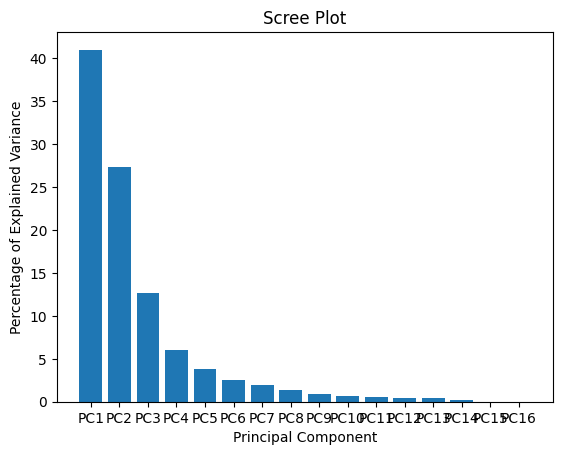

Loading ITables v2.7.3 from the internet... (need help?)


In [3]:
pp = pd.DataFrame(PCA_Matrix)
pca_matrix = pp.T.fillna(0)
scaler = StandardScaler(with_mean=True,with_std=False)
scaled_data = scaler.fit_transform(pca_matrix)
pca = PCA()
pca.fit(scaled_data)
pca_scores = pca.transform(scaled_data)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()
pp.T

### Explained variance by components

Text(0, 0.5, 'Cumulative Explained Variance')

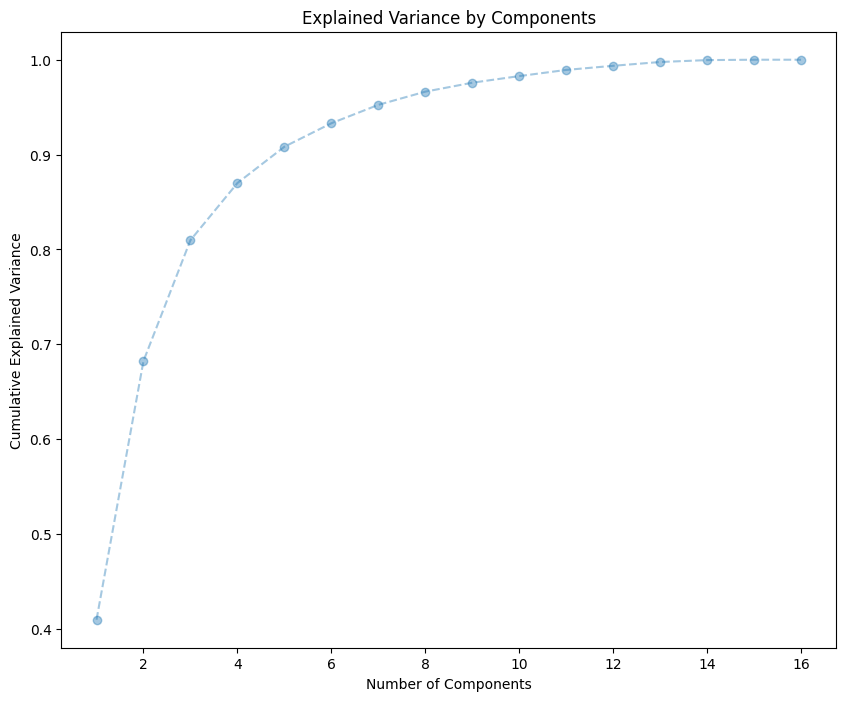

In [4]:
plt.figure( figsize = (10,8))
plt.plot(range(1,len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--', alpha=0.4)
plt.title("Explained Variance by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

### PCA plot 3D

In [5]:
#3D
import plotly.express as px
labels = ['U1_11092024', 'U1_20250525', 'U1_20250707', 'U1_20260129', 'U2_11092024', 'U2_20250707',
          'U11_11092024', 'U11_20250707', 'U11_20260129', 'U12_11092024',
          'U12_20260129', 'U4_1_20260129', 'U4_2_20260129', 'U4_atac_20260129',
          'U5A_20260129', 'U5B_20260129']
pca_df = pd.DataFrame(pca_scores, index=pp.columns,
                      columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])])
pca_df['label'] = labels
# print(pca_df)
#pca_df = pd.DataFrame(pca_data, columns=labels)
#show(pca_df)

# fig = plt.figure(figsize=(20, 12), dpi=300)
# ax = fig.add_subplot(111,projection='3d')
# x = pca_df['PC1']
# y = pca_df['PC2']
# z = pca_df['PC3']
# ax.scatter(x,y,z)
# plt.title('U snRNA PCA')
# ax.set_xlabel('PC1-{0}%'.format(per_var[0]))
# ax.set_ylabel('PC2-{0}%'.format(per_var[1]))
# ax.set_zlabel('PC3-{0}%'.format(per_var[2]))
# for sample in pca_df.index:
#     ax.text(pca_df['PC1'][sample], pca_df['PC2'][sample], pca_df['PC3'][sample], sample)

#plotly express
fig_newton = px.scatter_3d(data_frame=pca_df, x='PC1',y='PC2',z='PC3', hover_data=['label'],
                           labels={'PC1': 'PC1-{0}%'.format(per_var[0]),
                                   'PC2': 'PC2-{0}%'.format(per_var[1]),
                                   'PC3': 'PC3-{0}%'.format(per_var[2])})
fig_newton.show()

# Clustering and Centroid Calculation

Cluster # is defined from hierarchical clustering analysis

In [6]:
clustering = KMeans(n_clusters=3, random_state=42)
clustering.fit(pca_df[['PC1', 'PC2']])

pca_df['Cluster'] = clustering.labels_

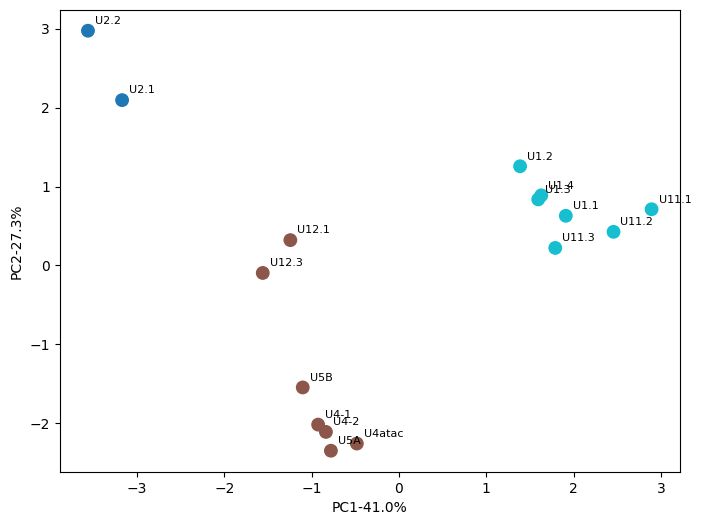

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='tab10', s=80)

for label, row in pca_df.iterrows():
    ax.annotate(label,
                (row['PC1'], row['PC2']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.xlabel('PC1-{0}%'.format(per_var[0]))
plt.ylabel('PC2-{0}%'.format(per_var[1]))
plt.show()


## DTW Analysis

In [8]:
labels = pca_matrix.index.tolist()
series = [pca_matrix.loc[label].values.astype(np.float64) for label in labels]

distance_matrix = dtw.distance_matrix_fast(series)
distance_matrix[np.isinf(distance_matrix)] = 0
distance_matrix = distance_matrix + distance_matrix.T - np.diag(np.diag(distance_matrix))

condensed = squareform(distance_matrix)
Z = linkage(condensed, method='ward')

# fig, ax = plt.subplots(figsize=(12, 5))
# dendrogram(Z, labels=labels, ax=ax, leaf_rotation=90)
# plt.tight_layout()
# plt.show()



condensed

# # Hierarchical clustering on DTW distances
# from scipy.cluster.hierarchy import linkage, dendrogram
# from scipy.spatial.distance import squareform

# condensed = squareform(distance_matrix)
# Z = linkage(condensed, method='ward')

# fig, ax = plt.subplots(figsize=(12, 5))
# dendrogram(Z, labels=labels, ax=ax, leaf_rotation=90)
# plt.tight_layout()
# plt.show()

array([ 4.83662843,  3.35823148,  3.55764799,  8.36912897,  9.37974676,
        4.37201277,  4.24692932,  4.28563739,  4.19481636,  3.97650913,
        5.65021321,  5.70681591,  4.88342899,  6.16512227,  6.09295758,
        5.14576549,  3.83260199,  7.32971137,  7.94979063,  7.22057106,
        6.72224799,  5.61793252,  5.69747499,  6.05694867,  7.25430467,
        7.3998561 ,  5.52075569,  7.00331675,  6.6475462 ,  3.23999433,
        6.95262182,  8.19249507,  4.36821451,  3.86719003,  3.24627917,
        3.96548093,  4.14365488,  4.9542225 ,  4.67346397,  3.94384166,
        5.11470455,  5.23558971,  7.56130293,  8.02387327,  5.2353854 ,
        5.28131391,  5.36318051,  5.0128478 ,  5.28415209,  6.73057525,
        6.61852061,  5.28300565,  6.70225173,  6.22024154,  2.92524228,
        8.15001594,  8.09863605,  7.03083453,  6.77030452,  6.57195531,
        8.48433866,  7.81237266,  6.96475474,  6.62610159,  4.94330025,
        9.53884918,  9.07413104,  8.84745033,  7.77162742,  7.94

In [9]:

series = pca_matrix
series = [pca_matrix.loc[label].values.astype(np.float64) for label in labels]
X = np.array(series)
km = TimeSeriesKMeans(n_clusters=3, metric='dtw', random_state=42)
clusters = km.fit_predict(X)

cluster = pd.DataFrame({'Sample': labels, 'Cluster': clusters})
cluster.set_index('Sample')


Loading ITables v2.7.3 from the internet... (need help?)


In [10]:
# km.cluster_centers_ is the DBA centroid per cluster (from your TimeSeriesKMeans)
centroids = km.cluster_centers_.squeeze()  # shape: (n_clusters, length)

warped_profiles = {}

for cluster_id in range(km.n_clusters):
    centroid = centroids[cluster_id]

    # Get samples in this cluster
    samples_in_cluster = [
        (label, profile)
        for label, profile, c in zip(labels, series, clusters)
        if c == cluster_id
    ]

    # Warp each sample in this cluster to its cluster's centroid
    for sample_label, sample_profile in samples_in_cluster:
        path = dtw.warping_path(sample_profile, centroid)

        warped = np.zeros(len(centroid))
        counts = np.zeros(len(centroid))

        for i, j in path:
            warped[j] += sample_profile[i]
            counts[j] += 1

        warped_profiles[sample_label] = warped / counts

dtw_aligned_matrix = pd.DataFrame(warped_profiles).T
dtw_aligned_matrix['Cluster'] = [clusters[labels.index(s)] for s in dtw_aligned_matrix.index]
dtw_aligned_matrix = dtw_aligned_matrix.sort_values('Cluster')
dtw_aligned_matrix

Loading ITables v2.7.3 from the internet... (need help?)


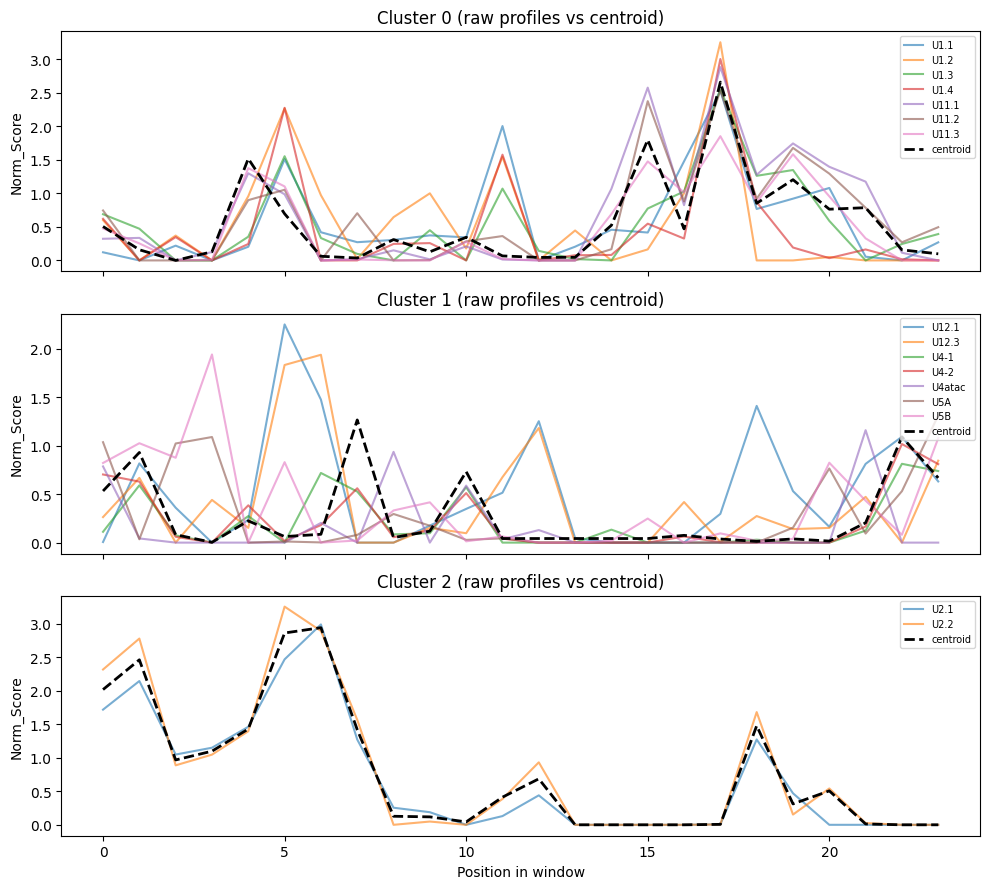

In [11]:
n_clusters = len(centroids)

fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 3 * n_clusters), sharex=True)

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]
    cluster_samples = dtw_aligned_matrix[dtw_aligned_matrix['Cluster'] == cluster_id].index

    for sample in cluster_samples:
        ax.plot(pca_matrix.loc[sample].values, alpha=0.6, label=sample)

    ax.plot(centroids[cluster_id], 'k--', linewidth=2, label='centroid')

    ax.set_title(f'Cluster {cluster_id} (raw profiles vs centroid)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylabel('Norm_Score')

axes[-1].set_xlabel('Position in window')
plt.tight_layout()
plt.show()

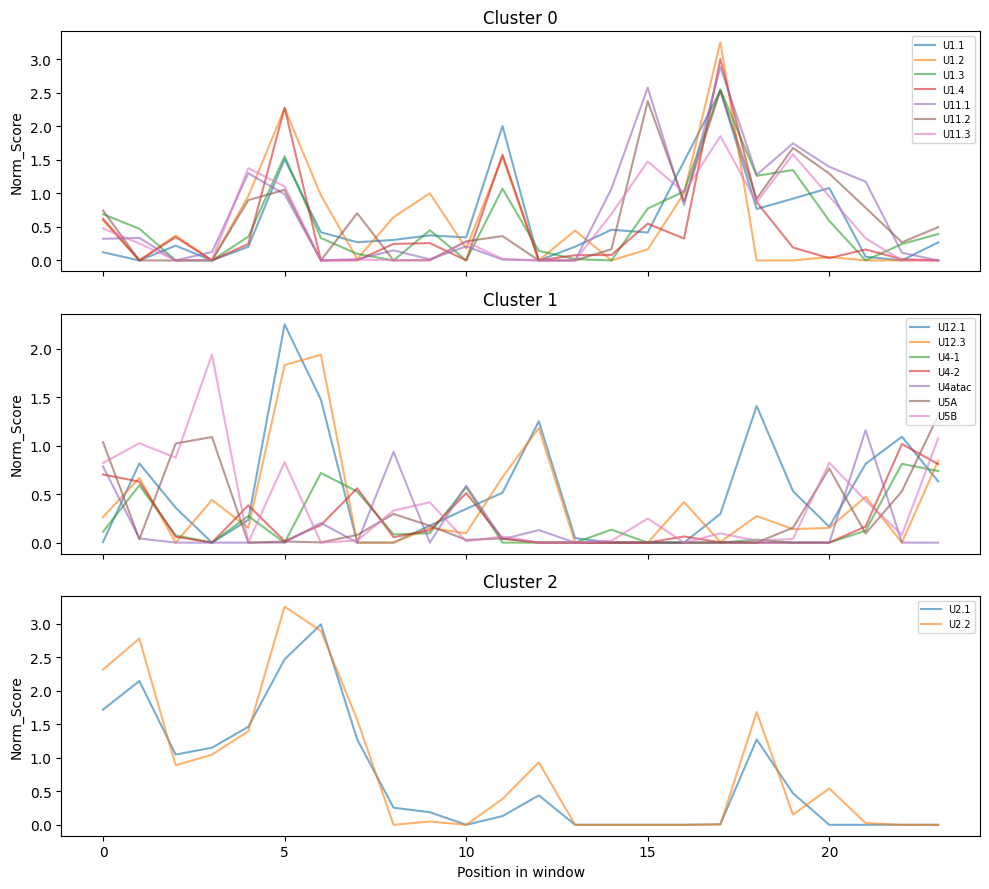

In [12]:
n_clusters = len(centroids)

fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 3 * n_clusters), sharex=True)

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]
    cluster_samples = dtw_aligned_matrix[dtw_aligned_matrix['Cluster'] == cluster_id].index

    for sample in cluster_samples:
        ax.plot(pca_matrix.loc[sample].values, alpha=0.6, label=sample)
  ax.plot(centroids[cluster_id], 'k--', linewidth=2, label='centroid')
    ax.set_title(f'Cluster {cluster_id}')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylabel('Norm_Score')

axes[-1].set_xlabel('Position in window')
plt.tight_layout()
plt.show()

In [13]:
# Use pca_matrix rows as the input profiles
labels = pca_matrix.index.tolist()
profiles = {label: pca_matrix.loc[label].values.astype(np.float64) for label in labels}

# Map sample → PCA cluster
pca_clusters = pca_df['Cluster'].to_dict()
n_clusters = pca_df['Cluster'].nunique()

# Compute DBA centroid per cluster from pca_matrix profiles
centroids = {}
for cluster_id in range(n_clusters):
    samples_in_cluster = [
        profiles[label] for label in labels
        if pca_clusters[label] == cluster_id
    ]
    centroids[cluster_id] = dtw_barycenter_averaging(np.array(samples_in_cluster)).ravel()

# Warp each sample to its cluster's centroid
warped_profiles = {}
for sample_label in labels:
    cluster_id = pca_clusters[sample_label]
    centroid = centroids[cluster_id]
    sample_profile = profiles[sample_label]

    path = dtw.warping_path(sample_profile, centroid)
    warped = np.zeros(len(centroid))
    counts = np.zeros(len(centroid))
    for i, j in path:
        warped[j] += sample_profile[i]
        counts[j] += 1
    warped_profiles[sample_label] = warped / counts

dtw_aligned_matrix = pd.DataFrame(warped_profiles).T
dtw_aligned_matrix['Cluster'] = [pca_clusters[s] for s in dtw_aligned_matrix.index]
dtw_aligned_matrix = dtw_aligned_matrix.sort_values('Cluster')
dtw_aligned_matrix


Loading ITables v2.7.3 from the internet... (need help?)


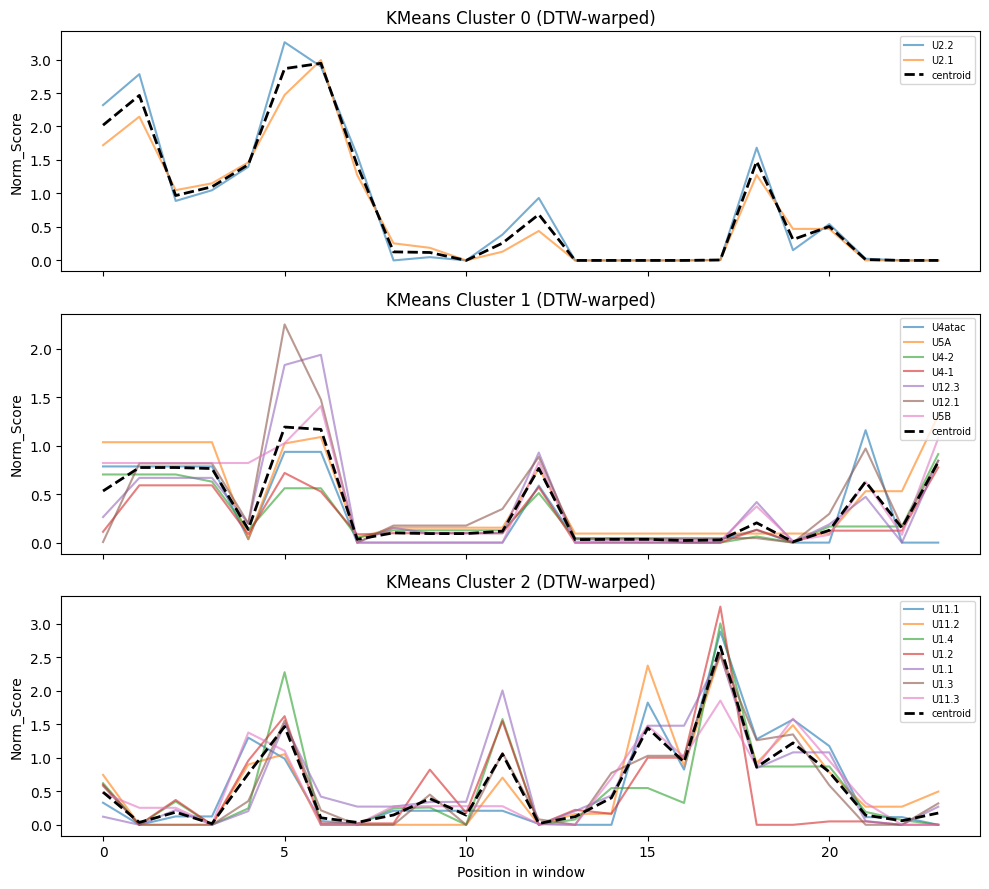

In [14]:
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 3 * n_clusters), sharex=True)

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]
    cluster_samples = dtw_aligned_matrix[dtw_aligned_matrix['Cluster'] == cluster_id].drop(columns='Cluster')

    for sample, row in cluster_samples.iterrows():
        ax.plot(row.values, alpha=0.6, label=sample)

    ax.plot(centroids[cluster_id], 'k--', linewidth=2, label='centroid')
    ax.set_title(f'KMeans Cluster {cluster_id} (DTW-warped)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylabel('Norm_Score')

axes[-1].set_xlabel('Position in window')
plt.tight_layout()
plt.show()

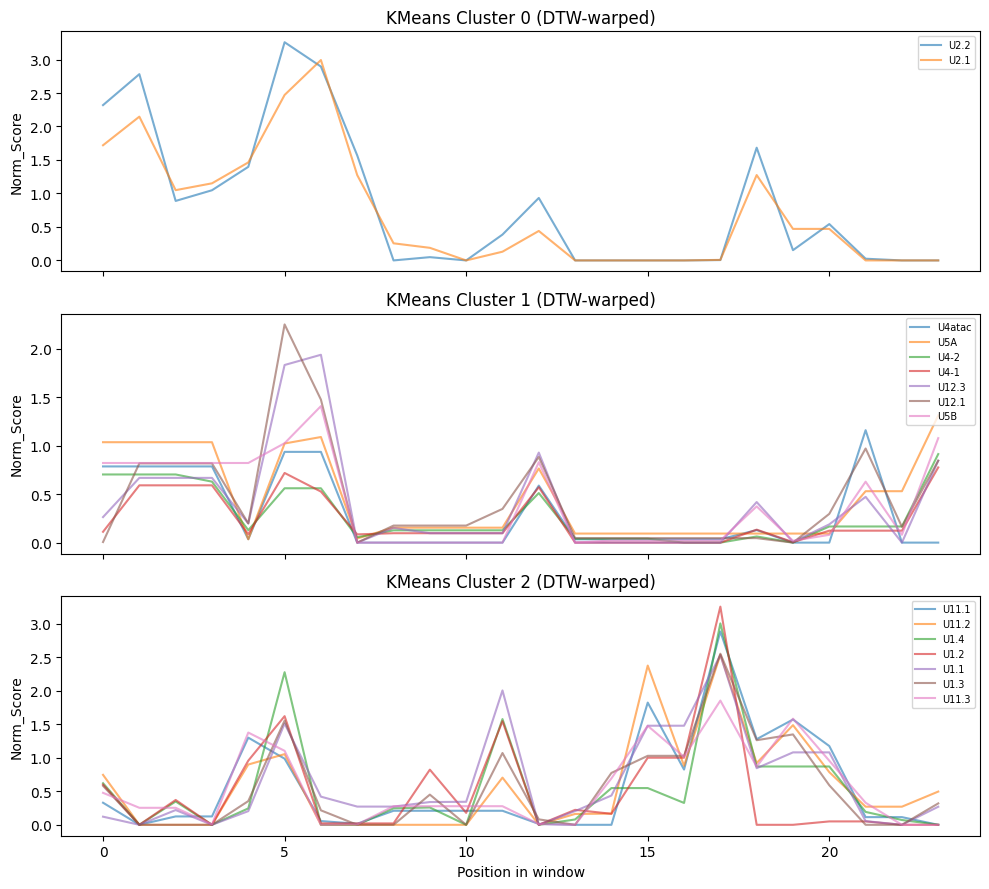

In [24]:
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 3 * n_clusters), sharex=True)

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]
    cluster_samples = dtw_aligned_matrix[dtw_aligned_matrix['Cluster'] == cluster_id].drop(columns='Cluster')

    for sample, row in cluster_samples.iterrows():
        ax.plot(row.values, alpha=0.6, label=sample)

    #     ax.plot(centroids[cluster_id], 'k--', linewidth=2, label='centroid')

    ax.set_title(f'KMeans Cluster {cluster_id} (DTW-warped)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylabel('Norm_Score')

axes[-1].set_xlabel('Position in window')
plt.tight_layout()
plt.show()

PCA and Correlation of DTW data

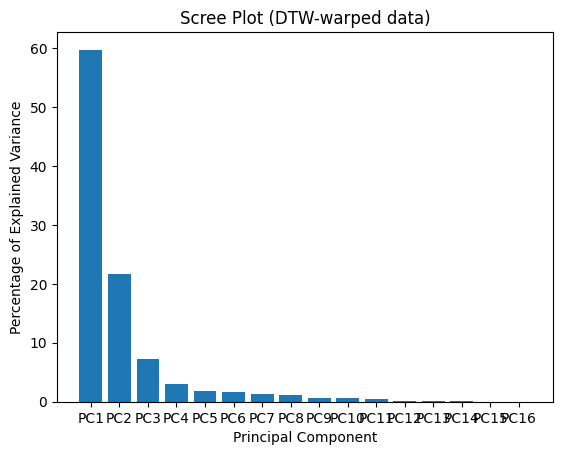

In [15]:
dtw_data = dtw_aligned_matrix.drop(columns='Cluster')

dtw_scaler = StandardScaler(with_mean=True, with_std=False)
dtw_data.columns = dtw_data.columns.astype(str)  # Convert column names to strings
dtw_scaled_data = dtw_scaler.fit_transform(dtw_data)

dtw_pca = PCA()
dtw_pca.fit(dtw_scaled_data)
dtw_pca_scores = dtw_pca.transform(dtw_scaled_data)
dtw_per_var = np.round(dtw_pca.explained_variance_ratio_ * 100, decimals=1)
dtw_labels = ['PC' + str(x) for x in range(1, len(dtw_per_var) + 1)]

plt.bar(x=range(1, len(dtw_per_var) + 1), height=dtw_per_var, tick_label=dtw_labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot (DTW-warped data)')
plt.show()

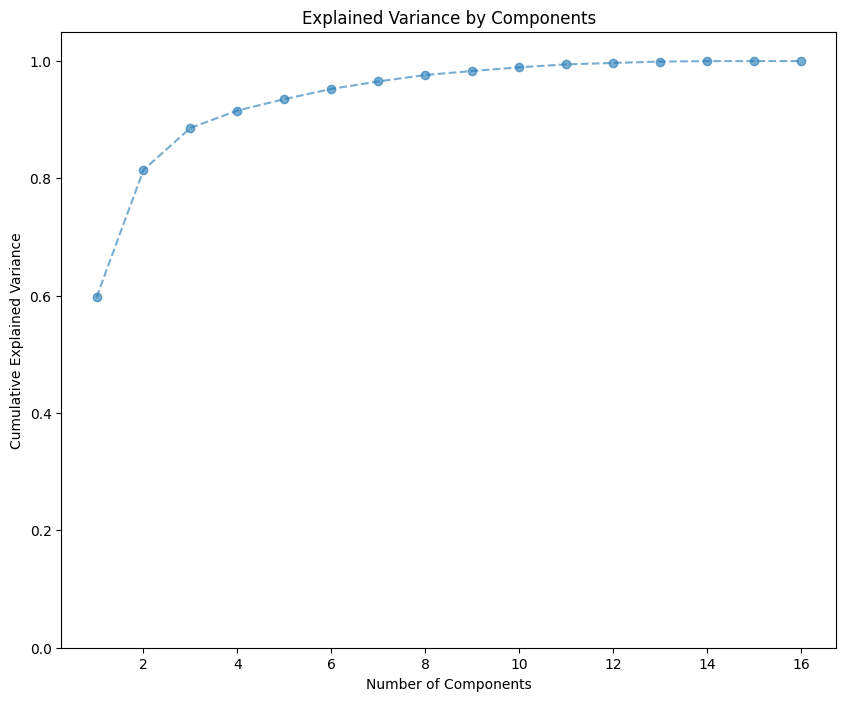

In [16]:
plt.figure(figsize=(10, 8))
plt.plot(range(1, len(dtw_pca.explained_variance_ratio_) + 1),
         dtw_pca.explained_variance_ratio_.cumsum(),
         marker='o', linestyle='--', alpha=0.6)
plt.title("Explained Variance by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.show()

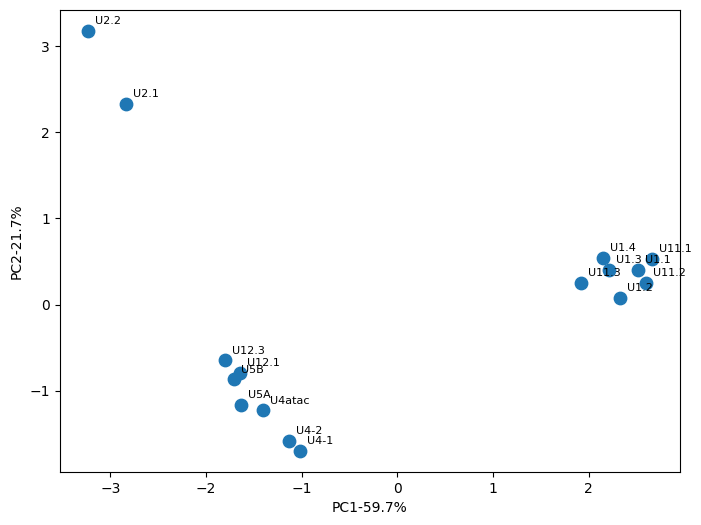

In [17]:
# DTW PCA
labels = dtw_data.index.tolist()

dtw_pca_df = pd.DataFrame(
    dtw_pca_scores,
    index=dtw_data.index,
    columns=[f'PC{i+1}' for i in range(dtw_pca_scores.shape[1])]
)
dtw_pca_df['label'] = labels

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dtw_pca_df['PC1'], dtw_pca_df['PC2'], s=80)

for label, row in dtw_pca_df.iterrows():
    ax.annotate(label, (row['PC1'], row['PC2']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel(f'PC1-{dtw_per_var[0]}%')
ax.set_ylabel(f'PC2-{dtw_per_var[1]}%')
plt.show()

In [18]:
for sample in labels:
    original = profiles[sample]
    warped = dtw_aligned_matrix.loc[sample].drop('Cluster').values
    diff = np.abs(original - warped).max()
    print(f"{sample}: max diff = {diff:.4f}")

U2.2: max diff = 0.0000
U2.1: max diff = 0.4708
U4atac: max diff = 0.9367
U5A: max diff = 1.0879
U4-2: max diff = 0.8512
U4-1: max diff = 0.7189
U12.3: max diff = 0.6683
U12.1: max diff = 1.3648
U5B: max diff = 1.4089
U11.1: max diff = 1.0675
U11.2: max diff = 0.7035
U1.4: max diff = 0.8350
U1.2: max diff = 0.9509
U1.1: max diff = 1.0610
U1.3: max diff = 0.7733
U11.3: max diff = 0.2774


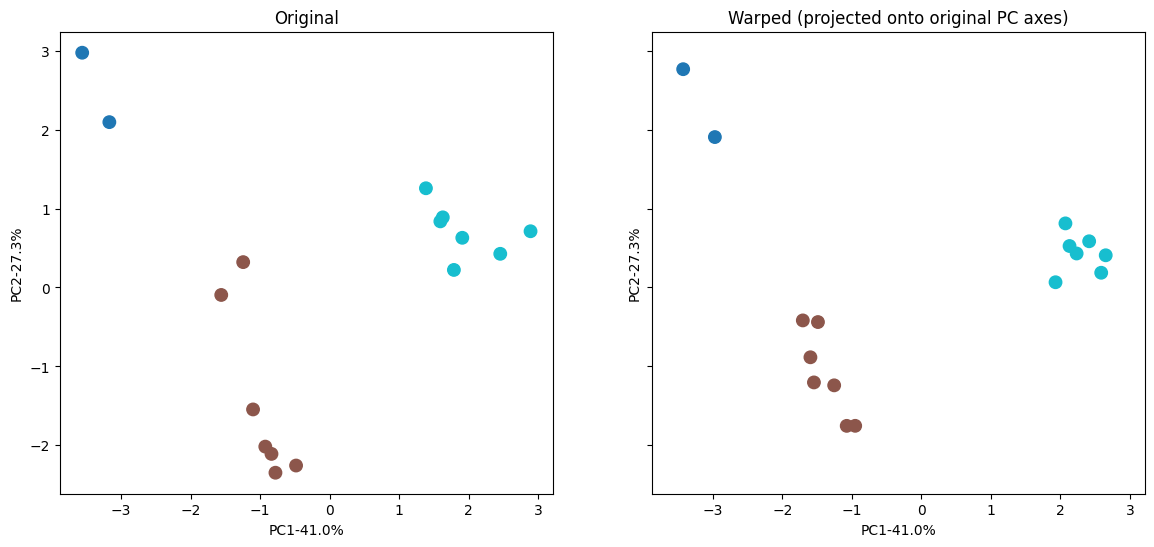

In [19]:
# Projection of DTW data onto ORIGINAL PCA axes
original_pca = pca
warped_in_orig_space = original_pca.transform(dtw_scaler.fit_transform(dtw_data))

warped_in_orig_df = pd.DataFrame(
    warped_in_orig_space[:, :2],
    index=dtw_data.index,
    columns=['PC1', 'PC2']
)
warped_in_orig_df['Cluster'] = dtw_aligned_matrix.loc[warped_in_orig_df.index, 'Cluster'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='tab10', s=80)
axes[0].set_title('Original')
axes[0].set_xlabel(f'PC1-{per_var[0]}%')
axes[0].set_ylabel(f'PC2-{per_var[1]}%')

axes[1].scatter(warped_in_orig_df['PC1'], warped_in_orig_df['PC2'],
                c=warped_in_orig_df['Cluster'], cmap='tab10', s=80)
axes[1].set_title('Warped (projected onto original PC axes)')
axes[1].set_xlabel(f'PC1-{per_var[0]}%')
axes[1].set_ylabel(f'PC2-{per_var[1]}%')

plt.show()

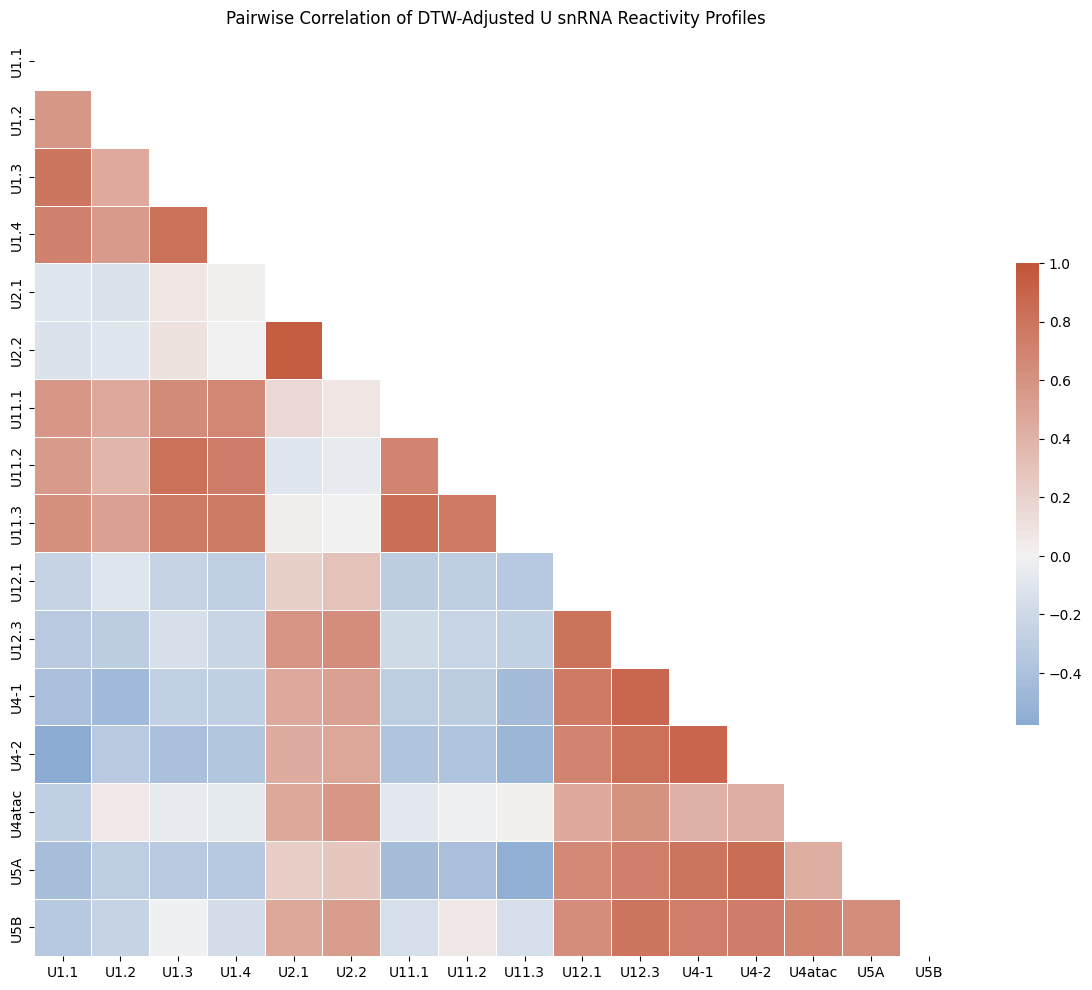

In [20]:
# Rebuild original correlation matrix to get the order
original_corr = pca_matrix.T.corr(method = 'spearman')
original_order = original_corr.index.tolist()

# Compute warped correlation and reorder to match
dtw_data = dtw_aligned_matrix.drop(columns='Cluster')
dtw_corr = dtw_data.T.corr(method = 'spearman')
dtw_corr = dtw_corr.loc[original_order, original_order]

# Plot
mask = np.triu(np.ones_like(dtw_corr, dtype=bool))

f, ax = plt.subplots(figsize=(15, 12))
cmap = sns.diverging_palette(250, 20, as_cmap=True)
sns.heatmap(dtw_corr, mask=mask, cmap=cmap, vmax=1, center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .5}).set(
    title='Pairwise Correlation of DTW-Adjusted U snRNA Reactivity Profiles'
)
plt.show()


###**Results**:
>



### **Discussion**

>

###Future Direction
>